# Update 3

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('../data/full_clean.csv')
df.head()

,headline,stance,body,headline_length_words,headline_length_chars,body_length_words,body_length_chars,overlap_ratio,headline_coverage,body_coverage,headline_clean,body_clean,headline_tokens,body_tokens,overlap_clean,headline_coverage_clean,body_coverage_clean
0,Police find mass graves with at least '15 bodi...,unrelated,Danny Boyle is directing the untitled film\r\n...,19,115,195,1105,0.013605,0.111111,0.015267,police find mass graf least 15 body near mexic...,danny boyle directing untitled film seth rogen...,"{'43', 'town', 'least', 'mexico', 'clash', '15...","{'female', 'say', 'set', 'apple', 'naught', 'c...",0.000000,0.000,0.000000
1,Hundreds of Palestinians flee floods in Gaza a...,agree,Hundreds of Palestinians were evacuated from t...,11,65,429,2608,0.043478,0.909091,0.043668,hundred palestinian flee flood gaza israel ope...,hundred palestinian evacuated home sunday morn...,"{'dam', 'hundred', 'israel', 'gaza', 'flood', ...","{'including', 'home', 'last', 'near', 'forcing...",0.040462,0.875,0.040698
2,"Christian Bale passes on role of Steve Jobs, a...",unrelated,30-year-old Moscow resident was hospitalized w...,16,91,194,1123,0.028777,0.250000,0.031496,christian bale pass role steve job actor repor...,30 year old moscow resident hospitalized wound...,"{'bale', 'part', 'pass', 'actor', 'steve', 'fe...","{'surgery', 'say', 'convinced', 'executed', 'c...",0.000000,0.000,0.000000
3,HBO and Apple in Talks for $15/Month Apple TV ...,unrelated,(Reuters) - A Canadian soldier was shot at the...,14,82,80,504,0.027027,0.166667,0.031250,hbo apple talk 15 month apple tv streaming ser...,reuters canadian soldier shot canadian war mem...,"{'hbo', 'apple', 'service', '15', 'month', 'tv...","{'ran', 'according', 'report', 'war', 'abocar'...",0.000000,0.000,0.000000
4,Spider burrowed through tourist's stomach and ...,disagree,"Fear not arachnophobes, the story of Bunbury's...",10,63,612,3433,0.021605,0.700000,0.021807,spider burrowed tourist stomach chest,fear arachnophobes story bunbury spiderman mig...,"{'tourist', 'spider', 'burrowed', 'chest', 'st...","{'think', 'child', 'say', 'legend', 'none', 'a...",0.014706,0.600,0.014851


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75385 entries, 0 to 75384
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   headline                 75385 non-null  object 
 1   stance                   75385 non-null  object 
 2   body                     75385 non-null  object 
 3   headline_length_words    75385 non-null  int64  
 4   headline_length_chars    75385 non-null  int64  
 5   body_length_words        75385 non-null  int64  
 6   body_length_chars        75385 non-null  int64  
 7   overlap_ratio            75385 non-null  float64
 8   headline_coverage        75385 non-null  float64
 9   body_coverage            75385 non-null  float64
 10  headline_clean           75385 non-null  object 
 11  body_clean               75385 non-null  object 
 12  headline_tokens          75385 non-null  object 
 13  body_tokens              75385 non-null  object 
 14  overlap_clean         

In [7]:
# Separate the dataset by stance
df_unrelated = df[df['stance'] == 'unrelated']
df_discuss = df[df['stance'] == 'discuss']
df_agree = df[df['stance'] == 'agree']
df_disagree = df[df['stance'] == 'disagree']

# Aggressively undersample 'unrelated' to exactly 15,000 rows
# random_state ensures reproducibility
df_unrelated_sampled = df_unrelated.sample(n=15000, random_state=42)

# Recombine the dataset (keeping discuss, agree, and disagree whole)
base_df = pd.concat([
    df_unrelated_sampled, 
    df_discuss, 
    df_agree, 
    df_disagree
], ignore_index=True)

# Drop the memory-heavy and redundant columns
columns_to_drop = [
    'headline_tokens', 'body_tokens', 
    'headline_length_chars', 'body_length_chars',
    'overlap_ratio', 'headline_coverage', 'body_coverage'
]
base_df = base_df.drop(columns=columns_to_drop)

# Shuffle the dataset so the classes are mixed
base_df = base_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=== Base Dataset Ready for Augmentation ===")
print(base_df['stance'].value_counts())
print("\nRemaining Columns:", base_df.columns.tolist())

=== Base Dataset Ready for Augmentation ===
stance
unrelated    15000
discuss      13373
agree         5581
disagree      1537
Name: count, dtype: int64

Remaining Columns: ['headline', 'stance', 'body', 'headline_length_words', 'body_length_words', 'headline_clean', 'body_clean', 'overlap_clean', 'headline_coverage_clean', 'body_coverage_clean']


## Data Augmentation

In [ ]:
# store for later use

base_df.to_csv('../data/base_df.csv', index=False)

In [ ]:
# !pip install nlpaug nltk

### 1. EDA - Easy Data Augmentation

In [12]:
import nltk

nltk.download("averaged_perceptron_tagger_eng")
nltk.download("averaged_perceptron_tagger")  # older NLTK / fallback
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")  # NLTK 3.8+ tokenization

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already

True

In [13]:
import nlpaug.augmenter.word as naw
from tqdm import tqdm # Gives us a nice progress bar

# Initialize the synonym augmenter (5% replacement rate)
# We use WordNet. It is fast and runs locally.
aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.05)

print("Starting Augmentation...")

synthetic_rows = []

# --- 1. Augment 'agree' (1x multiplier) ---
print("Augmenting 'agree' class (1x)...")
df_agree = base_df[base_df['stance'] == 'agree']

for _, row in tqdm(df_agree.iterrows(), total=len(df_agree)):
    # Augment the raw body
    new_body = aug.augment(row['body'])[0]
    
    # We will leave the headline alone for now (we can back-translate it later)
    new_headline = row['headline'] 
    
    synthetic_rows.append({
        'headline': new_headline,
        'body': new_body,
        'stance': 'agree'
    })

# --- 2. Augment 'disagree' (4x multiplier) ---
print("Augmenting 'disagree' class (4x)...")
df_disagree = base_df[base_df['stance'] == 'disagree']

for _, row in tqdm(df_disagree.iterrows(), total=len(df_disagree)):
    # We want 4 unique synthetic copies per original article
    for _ in range(4):
        new_body = aug.augment(row['body'])[0]
        new_headline = row['headline']
        
        synthetic_rows.append({
            'headline': new_headline,
            'body': new_body,
            'stance': 'disagree'
        })

# --- 3. Combine it all into the Final Raw Dataset ---
synthetic_df = pd.DataFrame(synthetic_rows)
final_raw_df = pd.concat([base_df, synthetic_df], ignore_index=True)

# Shuffle the final dataset
final_raw_df = final_raw_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n=== Augmentation Complete ===")
print(final_raw_df['stance'].value_counts())

Starting Augmentation...
Augmenting 'agree' class (1x)...


100%|██████████| 5581/5581 [01:20<00:00, 69.70it/s]


Augmenting 'disagree' class (4x)...


100%|██████████| 1537/1537 [01:33<00:00, 16.47it/s]


=== Augmentation Complete ===
stance
unrelated    15000
discuss      13373
agree        11162
disagree      7685
Name: count, dtype: int64


#### Cleaning data and creating important features

In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Enable progress_apply for pandas
tqdm.pandas() 

# 1. Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()

# --- STEP 1: TEXT CLEANING FUNCTION ---
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation & special chars
    
    # Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

print("1. Cleaning text (Lowercasing, Stopwords, Lemmatization)...")
final_raw_df['headline_clean'] = final_raw_df['headline'].progress_apply(clean_text)
final_raw_df['body_clean'] = final_raw_df['body'].progress_apply(clean_text)

# --- STEP 2: LENGTH FEATURES ---
print("\n2. Calculating word lengths...")
final_raw_df['headline_length_words'] = final_raw_df['headline'].apply(lambda x: len(str(x).split()))
final_raw_df['body_length_words'] = final_raw_df['body'].apply(lambda x: len(str(x).split()))

1. Cleaning text (Lowercasing, Stopwords, Lemmatization)...


100%|██████████| 47220/47220 [00:42<00:00, 1111.85it/s]



2. Calculating word lengths...


In [16]:
# --- STEP 3: OVERLAP & COVERAGE FEATURES ---
print("\n3. Calculating semantic overlap and coverage...")
def get_overlap_features(row):
    head_tokens = set(str(row['headline_clean']).split())
    body_tokens = set(str(row['body_clean']).split())
    
    intersection = len(head_tokens.intersection(body_tokens))
    union = len(head_tokens.union(body_tokens))
    
    # Calculate ratios (with safe division to prevent zero-division errors)
    overlap = intersection / union if union > 0 else 0
    head_cov = intersection / len(head_tokens) if len(head_tokens) > 0 else 0
    body_cov = intersection / len(body_tokens) if len(body_tokens) > 0 else 0
    
    return pd.Series([overlap, head_cov, body_cov])

final_raw_df[['overlap_clean', 'headline_coverage_clean', 'body_coverage_clean']] = final_raw_df.progress_apply(get_overlap_features, axis=1)


3. Calculating semantic overlap and coverage...


100%|██████████| 47220/47220 [00:05<00:00, 8288.45it/s] 


In [17]:
# --- STEP 4: VADER SENTIMENT FEATURES ---
print("\n4. Extracting VADER sentiment scores...")
# Note: Sentiment is calculated on the RAW text to preserve emotion/punctuation
final_raw_df['headline_sentiment'] = final_raw_df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])
final_raw_df['body_sentiment'] = final_raw_df['body'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Calculate the sentiment gap
final_raw_df['sentiment_gap'] = abs(final_raw_df['headline_sentiment'] - final_raw_df['body_sentiment'])

print("\n=== Feature Engineering Complete! ===")
print("Final Data Shape:", final_raw_df.shape)


4. Extracting VADER sentiment scores...


100%|██████████| 47220/47220 [02:12<00:00, 356.27it/s]


=== Feature Engineering Complete! ===
Final Data Shape: (47220, 13)


In [19]:
# --- STEP 5: SAVE THE MASTER DATASET ---
# Save this master dataset so you never have to run augmentation/cleaning again!
import os
os.makedirs('data/interim', exist_ok=True)
final_raw_df.to_csv('../data/interim/soft_balanced_final.csv', index=False)
print("Saved successfully to 'data/interim/soft_balanced_final.csv'")

Saved successfully to 'data/interim/soft_balanced_final.csv'


In [20]:
final_raw_df.head()

,headline,stance,body,headline_length_words,body_length_words,headline_clean,body_clean,overlap_clean,headline_coverage_clean,body_coverage_clean,headline_sentiment,body_sentiment,sentiment_gap
0,Unverified video shows beheading of aid worker...,unrelated,New York City continues to seek ways to cut do...,9,415,unverified video show beheading aid worker dav...,new york city continues seek way cut large num...,0.000000,0.000000,0.000000,0.0000,-0.9863,0.9863
1,Poster girl in fight against ISIS is beheaded ...,unrelated,A graphic circulating online claims that Mitt ...,11,254,poster girl fight isi beheaded terror group,graphic circulating online claim mitt romney s...,0.010309,0.142857,0.010989,-0.7184,0.6956,1.4140
2,Pope Francis turns out not to have made pets i...,disagree,NEW YORK — Pope Francis has given hope to gays...,12,420,pope francis turn made pet heaven comment,new york pope francis given hope gay unmarried...,0.023392,0.571429,0.023810,0.5106,0.9683,0.4577
3,Texas plumber's truck spotted in Syria: 'We ha...,unrelated,President Obama said Wednesday that the United...,15,1547,texas plumber truck spotted syria nothing terror,president obama said wednesday united state vi...,0.001852,0.142857,0.001873,-0.5267,-0.9940,0.4673
4,James Foley remembered as 'brave and tireless'...,agree,#ISIS beheads photojournalist James Wright Fol...,8,17,james foley remembered brave tireless journalist,isi beheads photojournalist james wright foley...,0.133333,0.333333,0.181818,0.5267,0.0000,0.5267


In [21]:
final_raw_df['stance'].value_counts()

stance
unrelated    15000
discuss      13373
agree        11162
disagree      7685
Name: count, dtype: int64

In [22]:
final_raw_df.shape

(47220, 13)

<Axes: ylabel='count'>

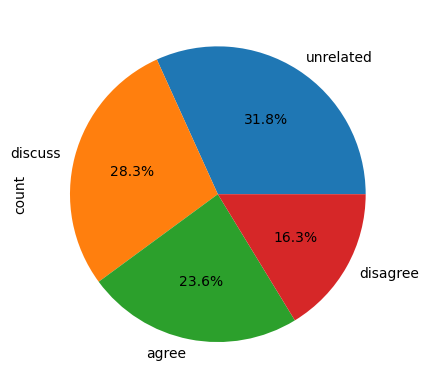

In [23]:
final_raw_df['stance'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [26]:
# !pip install spacy
# !python -m spacy download en_core_web_sm

In [25]:
# NER overlap

import spacy

tqdm.pandas()

# Load the pre-trained spaCy model
# Disable parser and lemmatizer to make it run much faster
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])

def get_ner_overlap(row):
    # Pass the RAW text into spaCy
    head_doc = nlp(str(row['headline']))
    body_doc = nlp(str(row['body']))
    
    # Extract entities and lowercase them so "Tim Cook" matches "tim cook"
    head_ents = set([ent.text.lower() for ent in head_doc.ents])
    body_ents = set([ent.text.lower() for ent in body_doc.ents])
    
    # Calculate overlap metrics
    intersection = len(head_ents.intersection(body_ents))
    union = len(head_ents.union(body_ents))
    
    # Calculate ratio (with safe division)
    overlap_ratio = intersection / union if union > 0 else 0.0
    
    # Return both the raw count of shared entities and the ratio
    return pd.Series([intersection, overlap_ratio])

print("Extracting Named Entities and calculating overlap (This may take a few minutes)...")

# Assuming your dataframe is currently called final_raw_df
final_raw_df[['ner_overlap_count', 'ner_overlap_ratio']] = final_raw_df.progress_apply(get_ner_overlap, axis=1)

print("\n=== NER Feature Engineering Complete! ===")
print(final_raw_df[['headline', 'ner_overlap_count', 'ner_overlap_ratio']].head())

# Now resave the updated dataframe!
final_raw_df.to_csv('../data/interim/soft_balanced_final.csv', index=False)

Extracting Named Entities and calculating overlap (This may take a few minutes)...


100%|██████████| 47220/47220 [41:23<00:00, 19.02it/s]    



=== NER Feature Engineering Complete! ===
                                            headline  ner_overlap_count  \
0  Unverified video shows beheading of aid worker...                0.0   
1  Poster girl in fight against ISIS is beheaded ...                0.0   
2  Pope Francis turns out not to have made pets i...                1.0   
3  Texas plumber's truck spotted in Syria: 'We ha...                1.0   
4  James Foley remembered as 'brave and tireless'...                0.0   

   ner_overlap_ratio  
0           0.000000  
1           0.000000  
2           0.038462  
3           0.008621  
4           0.000000  


In [28]:
final_raw_df.head()
# final_raw_df['stance'].value_counts()
# final_raw_df.shape
# final_raw_df['stance'].value_counts().plot(kind='pie', autopct='%1.1f%%')


,headline,stance,body,headline_length_words,body_length_words,headline_clean,body_clean,overlap_clean,headline_coverage_clean,body_coverage_clean,headline_sentiment,body_sentiment,sentiment_gap,ner_overlap_count,ner_overlap_ratio
0,Unverified video shows beheading of aid worker...,unrelated,New York City continues to seek ways to cut do...,9,415,unverified video show beheading aid worker dav...,new york city continues seek way cut large num...,0.000000,0.000000,0.000000,0.0000,-0.9863,0.9863,0.0,0.000000
1,Poster girl in fight against ISIS is beheaded ...,unrelated,A graphic circulating online claims that Mitt ...,11,254,poster girl fight isi beheaded terror group,graphic circulating online claim mitt romney s...,0.010309,0.142857,0.010989,-0.7184,0.6956,1.4140,0.0,0.000000
2,Pope Francis turns out not to have made pets i...,disagree,NEW YORK — Pope Francis has given hope to gays...,12,420,pope francis turn made pet heaven comment,new york pope francis given hope gay unmarried...,0.023392,0.571429,0.023810,0.5106,0.9683,0.4577,1.0,0.038462
3,Texas plumber's truck spotted in Syria: 'We ha...,unrelated,President Obama said Wednesday that the United...,15,1547,texas plumber truck spotted syria nothing terror,president obama said wednesday united state vi...,0.001852,0.142857,0.001873,-0.5267,-0.9940,0.4673,1.0,0.008621
4,James Foley remembered as 'brave and tireless'...,agree,#ISIS beheads photojournalist James Wright Fol...,8,17,james foley remembered brave tireless journalist,isi beheads photojournalist james wright foley...,0.133333,0.333333,0.181818,0.5267,0.0000,0.5267,0.0,0.000000
